# Informasi Dataset

Dataset yang digunakan mencakup sebuah estimasi level obesitas individual yang berasal dari Mexico, Peru, dan Colombia. Dataset terdiri dari 17 kolom dan 2111 records yang berisi pola makan dan kondisi fisik seseorang. 23% dataset merupakan data asli yang diambil dari platform web dan 77% merupakan data sintetik (generated data) menggunakan tools Weka dan SMOTE.

Sumber Data :
Estimation of Obesity Levels Based On Eating Habits and Physical Condition  [Dataset]. (2019). UCI Machine Learning Repository. https://doi.org/10.24432/C5H31Z.

# Menentukan Pertanyaan Bisnis

- **Pertanyaan Bisnis 1** :

    **Faktor gaya hidup** apa saja (frekuensi aktivitas fisik, waktu penggunaan teknologi , dan konsumsi air ) yang paling membedakan kelompok individu dengan **berat badan normal** (*Normal_Weight*) dibandingkan kelompok **obesitas tingkat tertinggi** (*Obesity_Type_III*) dalam dataset ini?

- **Pertanyaan Bisnis 2:**

    Seberapa besar persentase individu dengan **riwayat keluarga overweight** yang masuk ke kategori obesitas (semua tipe), dibandingkan individu **tanpa riwayat keluarga**, dan apakah perbedaan ini konsisten di kedua kelompok gender?

- **Pertanyaan Bisnis 3:**

    Bagaimana **distribusi transportasi** yang digunakan oleh masing-masing kelompok tingkat obesitas, dan apakah penggunaan kendaraan bermotor lebih dominan pada kelompok obesitas berat dibandingkan berjalan/bersepeda?

# Import Library

In [3]:
# mengimport library yang akan digunakan
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import warnings
from scipy.stats import kstest
from scipy.stats import gaussian_kde

# Load Dataset

In [4]:
# meload data dari penyimpanan
df = pd.read_csv("/content/obesity.csv")
# melihat struktur data dengan menggunakan 5 data teratas
df.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


Berhasil memuat dataset yang digunakan, dataset ini memuat berbagai variabel yang dapat memiliki keterkaitan dengan obesitas

# Assessing & Cleaning Data

## Struktur Data


In [5]:
# melihat jumlah baris dan kolom pada dataset
df.shape

(2111, 17)


Dataset terdiri dari 2111 baris dan 17 kolom

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

## Mengecek Data Kosong

In [7]:
# Menampilkan data kosong tiap kolom
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


Tidak terdapat data *missing*

## Mengecek Data Duplikat

In [8]:
# Mengecek jumlah data duplikat
df.duplicated().sum()

np.int64(24)

## Menampilkan Data Duplikat

In [9]:
# Menampilkan data duplikat
duplicate_rows = df[df.duplicated(keep=False)]
print(duplicate_rows)

     Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
97   Female  21.0    1.52    42.0                             no   no   3.0   
98   Female  21.0    1.52    42.0                             no   no   3.0   
105  Female  25.0    1.57    55.0                             no  yes   2.0   
106  Female  25.0    1.57    55.0                             no  yes   2.0   
145    Male  21.0    1.62    70.0                             no  yes   2.0   
174    Male  21.0    1.62    70.0                             no  yes   2.0   
179    Male  21.0    1.62    70.0                             no  yes   2.0   
184    Male  21.0    1.62    70.0                             no  yes   2.0   
208  Female  22.0    1.69    65.0                            yes  yes   2.0   
209  Female  22.0    1.69    65.0                            yes  yes   2.0   
282  Female  18.0    1.62    55.0                            yes  yes   2.0   
295  Female  16.0    1.66    58.0                   

## Drop Data Duplikat

In [10]:
# Menghapus data duplikat
df.drop_duplicates(inplace=True)
df.shape

(2087, 17)

- Dataset terdiri atas 2087 baris dan 17 kolom
- Tidak terdapat missing value pada data, akan tetapi terdapat 24 data duplikat yang telah diperbaiki

# Feature Engineering

## Menambahkan Kolom BMI

In [11]:
# Menambahkan kolom BMI berdasarkan rumus BMI yaitu berat badan/tinggi badan^2
# BMI merupakan alat ukur standar untuk menilai apakah berat badan seseorang ideal, kurang, berlebih, atau obesitas
df['BMI'] = (df['Weight'] / (df['Height'] ** 2)).round(2)

## Menambahkan Kolom Flag Obesitas

In [12]:
# Menambahkan kolom is_obese (True jika NObeyesdad mengandung 'Obesity')
df['is_obese'] = df['NObeyesdad'].str.contains('Obesity')

# Menampilkan 5 data teratas dengan kolom baru
display(df[['NObeyesdad', 'is_obese']].head())

,NObeyesdad,is_obese
0,Normal_Weight,False
1,Normal_Weight,False
2,Normal_Weight,False
3,Overweight_Level_I,False
4,Overweight_Level_II,False


## Encoding Kolom 'NObeyesdad'

In [13]:
# Menambahkan kolom numerik untuk kolom 'NObeyesdad' menggunakan metode encoding
# Memberikan nilai numerik untuk tiap variabel katogerik pada kolom 'NObeyesdad'
obesity_mapping = {
    'Insufficient_Weight': 1,
    'Normal_Weight': 2,
    'Overweight_Level_I': 3,
    'Overweight_Level_II': 4,
    'Obesity_Type_I': 5,
    'Obesity_Type_II': 6,
    'Obesity_Type_III': 7
}

# Mengaplikasikan nilai numerik kepada variabel pada kolom 'NObeyesdad'
df['NObeyesdad_encoded'] = df['NObeyesdad'].map(obesity_mapping)

# Memprlihatkan hasil encoding kolom 'NObeyesdad'
display(df[['NObeyesdad', 'NObeyesdad_encoded']].head(5))

,NObeyesdad,NObeyesdad_encoded
0,Normal_Weight,2
1,Normal_Weight,2
2,Normal_Weight,2
3,Overweight_Level_I,3
4,Overweight_Level_II,4


## Encoding Kolom Kategorikal Spesifik

In [14]:
# menambahkan kolom numerik untuk tiap kolom kategorik
# memberikan nilai numerik untuk tiap kolom kategorik
gender_mapping = {'Female': 0, 'Male' : 1}
family_history_mapping = {'no': 0, 'yes': 1}
favc_mapping = {'no': 0, 'yes': 1}
caec_mapping = {'no': 1, 'Sometimes': 2, 'Frequently': 3, 'Always': 4}
smoke_mapping = {'no': 0, 'yes': 1}
scc_mapping = {'no': 0, 'yes': 1}
calc_mapping = {'no': 1, 'Sometimes': 2, 'Frequently': 3, 'Always': 4}
mtrans_mapping = {'Automobile': 0, 'Bike': 1, 'Motorbike': 2, 'Public_Transportation': 3, 'Walking': 4}

# mengaplikasikan nilai numerik pada variabel tiap kolom kategorik
df['gender_encoded'] = df['Gender'].map(gender_mapping)
df['family_history_with_overweight_encoded'] = df['family_history_with_overweight'].map(family_history_mapping)
df['FAVC_encoded'] = df['FAVC'].map(favc_mapping)
df['CAEC_encoded'] = df['CAEC'].map(caec_mapping)
df['SMOKE_encoded'] = df['SMOKE'].map(smoke_mapping)
df['SCC_encoded'] = df['SCC'].map(scc_mapping)
df['CALC_encoded'] = df['CALC'].map(calc_mapping)
df['MTRANS_encoded'] = df['MTRANS'].map(mtrans_mapping)

# memperlihatkan hasil encoding
display(df.head())

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,is_obese,NObeyesdad_encoded,gender_encoded,family_history_with_overweight_encoded,FAVC_encoded,CAEC_encoded,SMOKE_encoded,SCC_encoded,CALC_encoded,MTRANS_encoded
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,...,False,2,0,1,0,2,0,0,1,3
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,...,False,2,0,1,0,2,1,1,2,3
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,...,False,2,1,1,0,2,0,0,3,3
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,...,False,3,1,0,0,2,0,0,3,4
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,...,False,4,1,0,0,2,0,0,2,3


## Struktur Data Setelah Pembersihan dan Feature Engineering

In [15]:
df.shape

(2087, 28)

- Baris yang sebelumnya berjumlah 2111 sekarang menjadi 2087 karena penghapusan data duplikat
- Kolom bertambah menjadi 28 karena adanya penambahan kolom BMI, kolom is_obese dan kolom numerik untuk kolom dengan variabel kategorik

In [16]:
# memperlihatkan struktur dan tipe data yang telah ditambahkan
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 28 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Gender                                  2087 non-null   object 
 1   Age                                     2087 non-null   float64
 2   Height                                  2087 non-null   float64
 3   Weight                                  2087 non-null   float64
 4   family_history_with_overweight          2087 non-null   object 
 5   FAVC                                    2087 non-null   object 
 6   FCVC                                    2087 non-null   float64
 7   NCP                                     2087 non-null   float64
 8   CAEC                                    2087 non-null   object 
 9   SMOKE                                   2087 non-null   object 
 10  CH2O                                    2087 non-null   float64
 

## Export Dataset yang Telah Diproses

In [17]:
# Menyimpan DataFrame yang telah diproses ke file CSV
output_file_path = 'obesity_processed.csv'
df.to_csv(output_file_path, index=False)
print(f"Dataset yang telah diproses berhasil disimpan ke: {output_file_path}")

Dataset yang telah diproses berhasil disimpan ke: obesity_processed.csv


# EDA

## Statistik Deskriptif

In [18]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI,NObeyesdad_encoded,gender_encoded,family_history_with_overweight_encoded,FAVC_encoded,CAEC_encoded,SMOKE_encoded,SCC_encoded,CALC_encoded,MTRANS_encoded
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,1.702674,86.858730,2.421466,2.701179,2.004749,1.012812,0.663035,29.765750,4.132247,0.504073,0.825108,0.883565,2.146143,0.021083,0.045999,1.729756,2.358888
std,6.368801,0.093186,26.190847,0.534737,0.764614,0.608284,0.853475,0.608153,8.024953,1.985747,0.500103,0.379966,0.320823,0.459494,0.143695,0.209533,0.517008,1.265402
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000,13.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,19.915937,1.630178,66.000000,2.000000,2.697467,1.590922,0.124505,0.000000,24.370000,2.000000,0.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.000000,3.000000
50%,22.847618,1.701584,83.101100,2.396265,3.000000,2.000000,1.000000,0.630866,28.900000,4.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,2.000000,3.000000
75%,26.000000,1.769491,108.015907,3.000000,3.000000,2.466193,1.678102,1.000000,36.095000,6.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,2.000000,3.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000,50.810000,7.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,4.000000,4.000000


###**Interpretasi Statistik Deskriptif :**

- Rata-rata umur individu pada dataset ~ 23 tahun dengan rentang yang cukup lebar dengan usia termuda 14 tahun dan tertua 61 tahun. Data ini mayoritas diisi oleh kalangan muda terbukti dengan sebagian besar data yang tersebar dari 20 hingga 26 tahun, sehingga data ini berkemungkinan lebih merepresentasikan kelompok usia muda.<P>

- Sementara itu rata-rata tinggi badan adalah 1,7 meter dengan standar deviasi 0.09 yang berarti sebaran tinggi tidak terlalu jauh terbukti dengan sebagian besar memiliki tinggi antara 1,63 meter hingga 1,77 meter.<P>

- Kemudian untuk berat badan memiliki rata-rata 83 kg dengan rentang yang cukup besar di 39 kg sampai 173 kg, ini juga dibuktikan dengan nilai standar deviasi yang cukup besar yaitu 26,19, mengindikasikan dataset mencakup berat yang cukup beragam.<P>

- Nilai BMI memiliki rata-rata 29,77 yang mana ini sudah di ambang overweight menuju obesity. Tercatat nilai BMI terendah yaitu 13 yang masuk kategori sangat kurus, sementara nilai tertinggi mencapai 50,82 yang telah memasuki kategori obesitas ekstrem.<P>

- Selanjutnya, jika dilihat dari variabel FCVC (Frekuensi Konsumsi Sayur), rata-rata berada di angka 2,42 dari rentang 1 hingga 3. Hal ini menunjukkan bahwa secara umum individu dalam dataset cukup sering mengonsumsi sayur, dengan sebagian besar berada di kisaran 2 hingga 3. Variasi data juga tidak terlalu besar (std ≈ 0,53), sehingga kebiasaan konsumsi sayur relatif homogen di antara responden.<P>

- Untuk NCP (Jumlah Makan Utama per Hari), rata-rata berada di angka 2,70 dengan median 3, yang mengindikasikan bahwa mayoritas individu makan sekitar 3 kali sehari. Rentangnya dari 1 hingga 4 kali, sehingga masih terdapat variasi pola makan, namun secara umum pola makan responden tergolong cukup teratur.<P>

- Pada variabel CH2O (Konsumsi Air Harian), rata-rata sebesar 2,00 (dalam skala 1–3), menunjukkan bahwa mayoritas individu memiliki konsumsi air yang cukup. Nilai minimum 1 dan maksimum 3 mengindikasikan adanya perbedaan kebiasaan hidrasi, tetapi dengan standar deviasi sekitar 0,61, variasinya masih tergolong moderat.<P>

- Sementara itu, FAF (Frekuensi Aktivitas Fisik) memiliki rata-rata 1,01 dengan rentang dari 0 hingga 3. Nilai ini menunjukkan bahwa tingkat aktivitas fisik individu cenderung rendah hingga sedang, dengan sebagian individu bahkan tidak melakukan aktivitas fisik sama sekali (nilai 0). Standar deviasi yang cukup besar (≈0,85) juga mengindikasikan adanya variasi yang cukup signifikan dalam aktivitas fisik antar individu.<P>

- Untuk TUE (Waktu Penggunaan Teknologi), rata-rata sebesar 0,66 dengan rentang 0 hingga 2. Hal ini menunjukkan bahwa sebagian besar individu memiliki penggunaan teknologi yang relatif rendah hingga sedang. Namun, dengan adanya nilai maksimum 2, terdapat sebagian individu dengan penggunaan teknologi yang cukup tinggi, yang berpotensi berkaitan dengan gaya hidup sedentary.<P>

- Variabel kategorikal yang telah diencoding juga memberikan gambaran menarik. Pada NObeyesdad_encoded, rata-rata sebesar 4,13 dari rentang 1 hingga 7, yang menunjukkan distribusi kategori obesitas cukup beragam dan cenderung berada di tingkat menengah. Hal ini sejalan dengan rata-rata BMI yang berada di ambang overweight menuju obesitas.<P>

- Untuk family_history_with_overweight_encoded, rata-rata sebesar 0,83 yang berarti sebagian besar individu memiliki riwayat keluarga dengan overweight. Hal ini dapat menjadi indikasi adanya faktor genetik atau pola hidup keluarga yang berkontribusi terhadap kondisi berat badan individu.<P>

- Pada FAVC (Frequent Consumption of High Calorie Food), rata-rata sebesar 0,88 yang menunjukkan mayoritas individu sering mengonsumsi makanan berkalori tinggi. Hal ini menjadi salah satu faktor penting yang dapat menjelaskan tingginya rata-rata BMI dalam dataset.<P>

- Variabel CAEC (Kebiasaan Makan di Luar Waktu Utama / Ngemil) memiliki rata-rata 2,15 (rentang 1–4), yang menunjukkan bahwa kebiasaan ngemil berada pada tingkat sedang. Artinya, cukup banyak individu yang memiliki kebiasaan makan di luar jam makan utama, yang berpotensi meningkatkan asupan kalori harian.<P>

- Untuk SCC (Monitoring Konsumsi Kalori), rata-rata hanya sebesar 0,046 yang menunjukkan bahwa hampir seluruh individu tidak memantau konsumsi kalorinya. Hal ini dapat menjadi salah satu faktor yang menyebabkan kurangnya kontrol terhadap berat badan.<P>

- Selanjutnya, CALC (Konsumsi Alkohol) memiliki rata-rata 1,73 (rentang 1–4), yang menunjukkan bahwa konsumsi alkohol berada pada tingkat rendah hingga sedang di sebagian besar individu.<P>

- Terakhir, pada MTRANS (Moda Transportasi) dengan rata-rata 2,36 (rentang 0–4), menunjukkan variasi dalam penggunaan transportasi. Nilai ini mengindikasikan bahwa sebagian individu mungkin menggunakan transportasi pasif (seperti kendaraan bermotor), yang dapat berkontribusi pada rendahnya aktivitas fisik.<P>

- Secara keseluruhan, pola yang terlihat menunjukkan bahwa dataset ini didominasi oleh individu dengan gaya hidup yang cenderung kurang aktif, konsumsi makanan berkalori tinggi yang cukup sering, serta minimnya kontrol terhadap asupan kalori. Kombinasi faktor-faktor ini konsisten dengan temuan bahwa rata-rata BMI berada pada kategori overweight hingga obesitas.



## Matriks Korelasi

In [19]:
# mengelompokkan kolom numerik menjadi list agar mudah digunakan
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Kolom Numerik :", numerical_cols)
# menghitung matriks korelasi antar kolom numerik
correlation_matrix_updated = df[numerical_cols].corr()

Kolom Numerik : ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'BMI', 'NObeyesdad_encoded', 'gender_encoded', 'family_history_with_overweight_encoded', 'FAVC_encoded', 'CAEC_encoded', 'SMOKE_encoded', 'SCC_encoded', 'CALC_encoded', 'MTRANS_encoded']


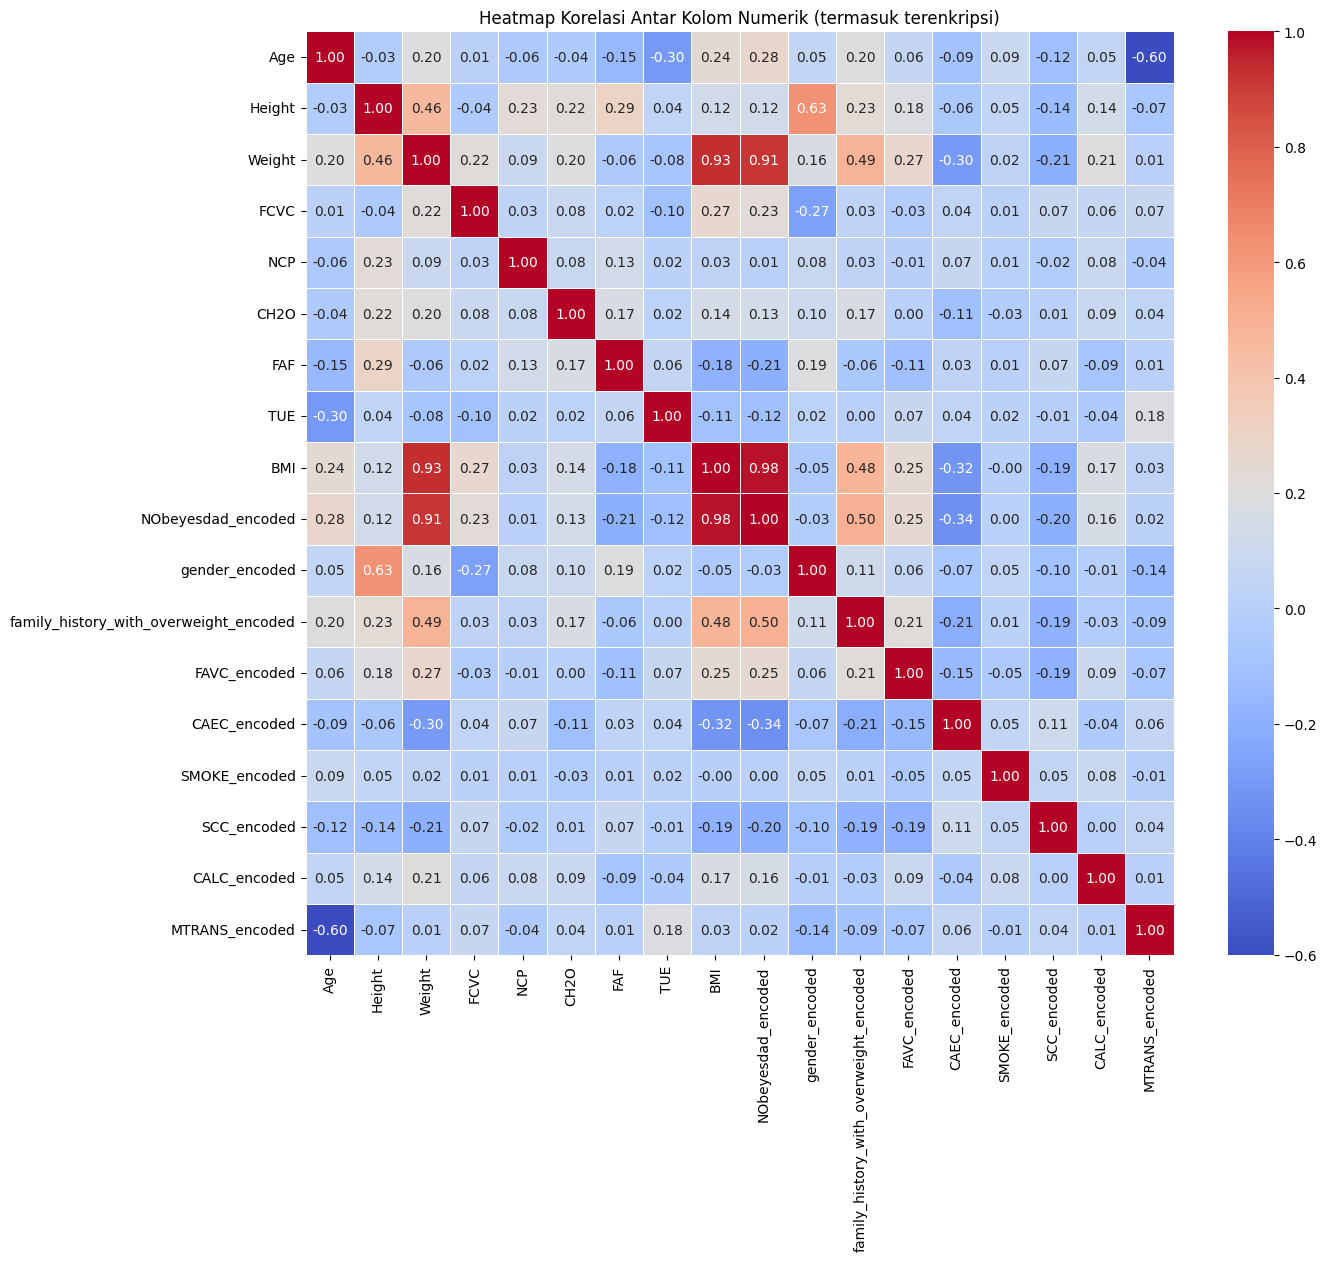

In [20]:
# membuat visualisasi matriks korelasi dengan menggunakan heatmap dengan warna coolwarm (merah = korelasi positif, biru = korelasi negatif)
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix_updated, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
# memberikan judul pada matriks korelasi dan menampilkan hasil
plt.title('Heatmap Korelasi Antar Kolom Numerik (termasuk terenkripsi)')
plt.show()

###**Interpretasi Matriks Korelasi:**
- Hubungan antara Weight dan BMI dengan korelasi sangat tinggi (≈ 0,93). Ini masuk akal karena BMI memang secara matematis dipengaruhi oleh berat badan. Selain itu, BMI dengan NObeyesdad (kategori obesitas) juga sangat tinggi (≈ 0,98), yang berarti variabel target ini hampir sepenuhnya ditentukan oleh BMI.<P>

- Selanjutnya, Weight dengan NObeyesdad juga memiliki korelasi tinggi (≈ 0,91), menunjukkan bahwa semakin besar berat badan, semakin tinggi kemungkinan masuk kategori obesitas. Ini memperkuat bahwa faktor fisik (terutama berat badan) menjadi penentu utama dibanding variabel gaya hidup lainnya.<P>

- Untuk variabel gender_encoded, terlihat korelasi sedang dengan Height (≈ 0,63), yang menunjukkan adanya perbedaan tinggi badan yang cukup jelas antar gender pada dataset ini. Selain itu, gender juga memiliki korelasi negatif kecil dengan FCVC (≈ -0,27) serta korelasi yang sangat lemah terhadap BMI dan NObeyesdad, sehingga pengaruh gender terhadap obesitas pada dataset ini relatif kecil. <P>

- Untuk faktor genetik, family_history_with_overweight memiliki korelasi sedang dengan NObeyesdad (≈ 0,50) dan BMI (≈ 0,48). Artinya, riwayat keluarga cukup berpengaruh terhadap kondisi obesitas, meskipun tidak sekuat faktor berat badan langsung.<P>

- CAEC (kebiasaan ngemil) justru memiliki korelasi negatif dengan BMI (≈ -0,32) dan NObeyesdad (≈ -0,34). <P>

- Untuk SCC (monitoring kalori), korelasinya negatif kecil dengan BMI (≈ -0,19), yang berarti individu yang memantau kalori cenderung memiliki BMI lebih rendah, walaupun pengaruhnya tidak besar.<P>

- Terakhir, Age dengan MTRANS (transportasi) memiliki korelasi negatif cukup kuat ≈ -0,60, yang menunjukkan semakin tua usia, kecenderungan penggunaan jenis transportasi tertentu berubah.<P>

## Histogram untuk Kolom Numerik

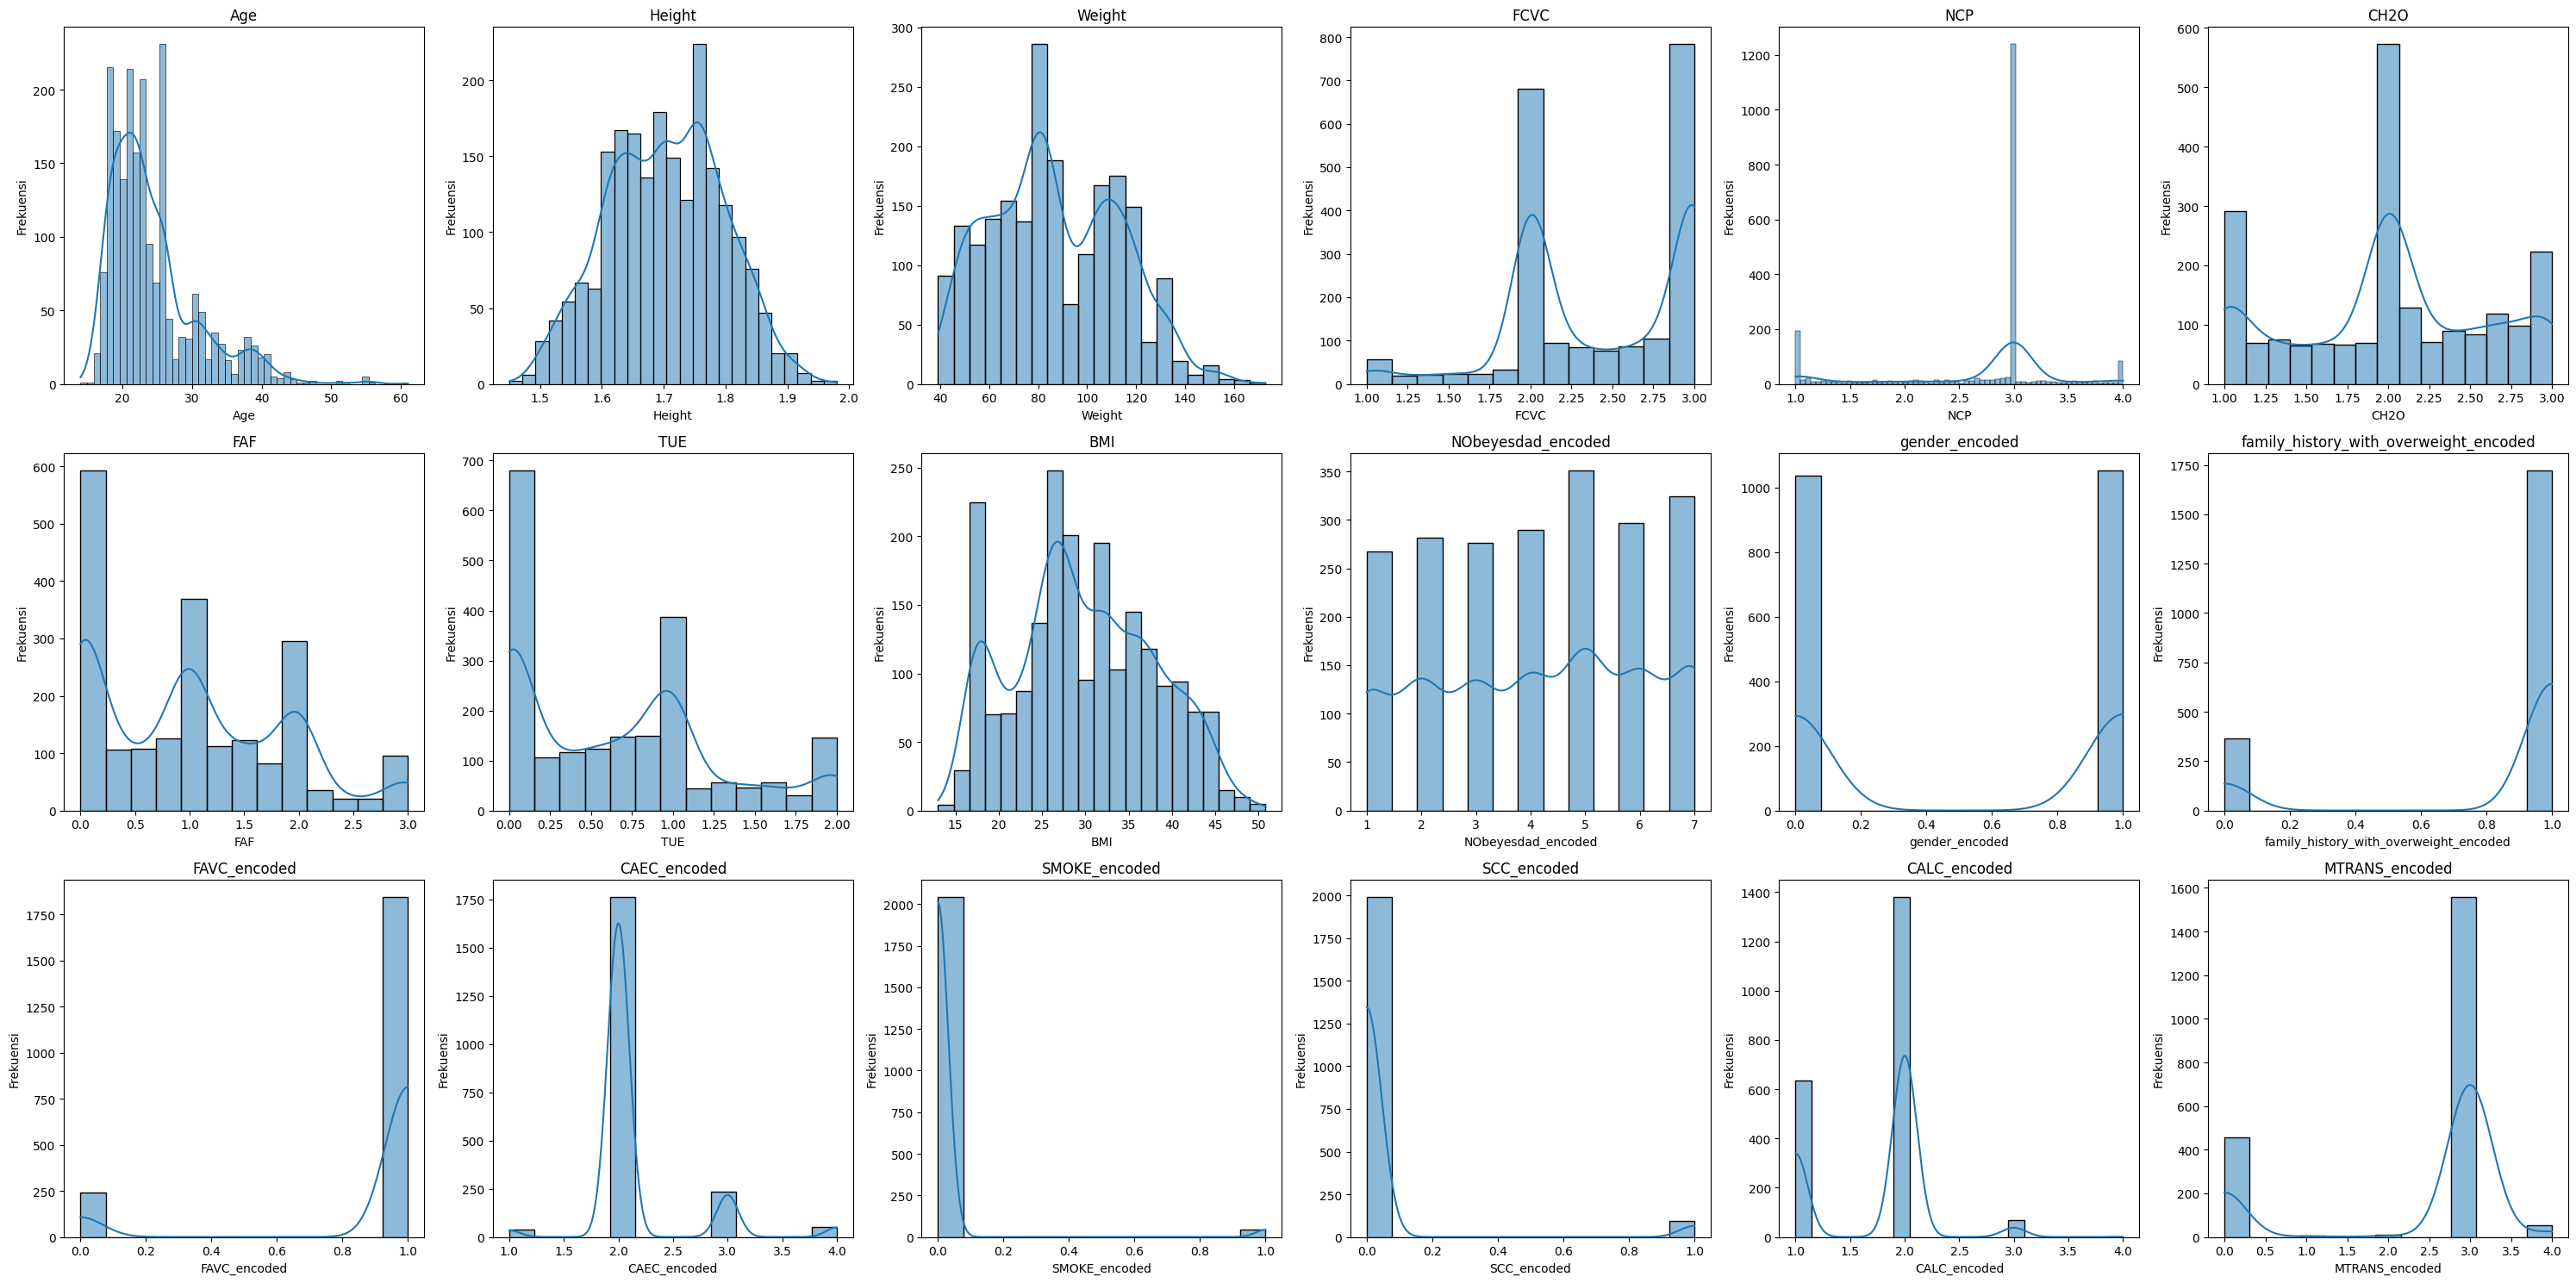

In [21]:
# membuat grid ukuran 4x4 untuk semua kolom numerik
fig, axes = plt.subplots(3, 6, figsize=(30, 15))
axes = axes.flatten()

# membuat histogram untuk setiap kolom numerik
for i, col in enumerate(numerical_cols):
    if i < len(axes):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'{col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frekuensi')
    else:
        break

# menghapus subplot yang tidak terpakai agar tampilan lebih rapi
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
# merapikan dan menampilkan chart
plt.tight_layout()
plt.show()

### **Interpretasi Histogram**
- Untuk Age, distribusi terlihat right-skewed, dengan konsentrasi terbesar di usia sekitar 18–25 tahun. Hal ini menjelaskan bahwa dataset didominasi usia muda, sementara usia yang lebih tua jumlahnya jauh lebih sedikit.<P>

- Pada Height, distribusi cenderung normal (simetris). Ini menunjukkan tinggi badan relatif homogen dan tidak banyak outlier ekstrem.<P>

- Sementara itu, Weight terlihat cukup menyebar dengan indikasi sedikit bimodal (dua puncak), yang kemungkinan mencerminkan adanya dua kelompok berbeda<P>

- Untuk FCVC (konsumsi sayur), distribusi cenderung menumpuk di nilai tinggi (sekitar 2–3), yang berarti mayoritas individu cukup sering mengonsumsi sayur.<P>

- Pada NCP (jumlah makan utama), distribusi sangat terkonsentrasi di angka 3, menunjukkan pola makan yang cukup seragam yaitu sekitar 3 kali sehari.<P>

- Variabel CH2O (konsumsi air) memiliki puncak di sekitar nilai 2, yang menandakan mayoritas individu memiliki konsumsi air pada tingkat sedang.<P>

- Untuk FAF (aktivitas fisik), distribusi condong ke kiri (banyak di nilai rendah), yang menunjukkan sebagian besar individu memiliki aktivitas fisik yang rendah.<P>

- Hal serupa juga terlihat pada TUE (penggunaan teknologi), di mana banyak individu berada pada nilai rendah, tetapi tetap ada sebagian dengan nilai tinggi, menunjukkan variasi penggunaan teknologi.<P>

- Pada BMI, distribusi cukup lebar dan cenderung right-skewed, dengan banyak individu berada di kisaran overweight hingga obesitas. Hal ini konsisten dengan rata-rata BMI sebelumnya yang cukup tinggi.<P>

- Untuk NObeyesdad (kategori obesitas), distribusi relatif tersebar di berbagai kategori, meskipun ada kecenderungan lebih banyak di kategori menengah hingga tinggi.<P>

- Untuk Gender, distribusi antara kedua gender relatif merata.<P>

- Variabel kategorikal biner seperti family_history_with_overweight dan FAVC sangat tidak seimbang (didominasi nilai 1), yang menunjukkan mayoritas individu memiliki riwayat keluarga overweight dan sering mengonsumsi makanan tinggi kalori.<P>

- Pada CAEC (kebiasaan ngemil), mayoritas berada di kategori tengah, menandakan kebiasaan ngemil cukup umum.<P>

- Pada variabel SMOKE , mayoritas berada di kategori tidak merokok, hanya sedikit individu yang merokok di dataset berikut.<P>

- Untuk SCC (monitoring kalori), distribusi sangat timpang di nilai 0, yang berarti hampir semua individu tidak memantau konsumsi kalorinya.<P>

- Variabel CALC (konsumsi alkohol) terkonsentrasi di nilai rendah hingga sedang, menunjukkan konsumsi alkohol tidak terlalu dominan dalam dataset.<P>

- Terakhir, MTRANS (transportasi) menunjukkan konsentrasi pada satu kategori utama, yang mengindikasikan mayoritas individu menggunakan jenis transportasi yang sama (kemungkinan kendaraan bermotor).<P>

## Uji Normalitas Kolom Numerik

In [22]:
# melakukan uji normalitas untuk melihat sebaran data
print("Uji Normalitas (Kolmogorov-Smirnov Test) untuk Kolom Numerik:")
for col in numerical_cols:
    # menghitung rata-rata dan standar deviasi tiap kolom
    mean = df[col].mean()
    std = df[col].std()

    # melakukan uji Kolmogorv-Smirnov
    # parameter 'norm' mengamsumsikan standar distribusi normal (mean = 0, std = 1
    # args digunakan untuk mengambil parameter langsung dari data yang digunakan
    stat, p = kstest(df[col], 'norm', args=(mean, std))

    print(f'\nKolom: {col}')
    print(f'Statistik Uji=%.3f, p=%.3f' % (stat, p))
    if p > 0.05:
        print('Kemungkinan berdistribusi normal (tidak menolak H0)')
    else:
        print('Tidak berdistribusi normal (menolak H0)')

Uji Normalitas (Kolmogorov-Smirnov Test) untuk Kolom Numerik:

Kolom: Age
Statistik Uji=0.160, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: Height
Statistik Uji=0.048, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: Weight
Statistik Uji=0.059, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: FCVC
Statistik Uji=0.174, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: NCP
Statistik Uji=0.341, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: CH2O
Statistik Uji=0.133, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: FAF
Statistik Uji=0.118, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: TUE
Statistik Uji=0.138, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: BMI
Statistik Uji=0.049, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: NObeyesdad_encoded
Statistik Uji=0.135, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: gender_encoded
Statistik Uji=0.343, p=0.000
Tidak berdistribusi normal (menolak H0)

Kolom: famil

### **Interpretasi Uji Normalitas :**
- Berdasarkan uji normalitas Kolmogorov_Smirnov dengan alpha = 5%, dapat disimpulkan bahwa seluruh distribusi kolom numerik tidak berdistribusi normal dengan keputusan menolak H0

## Boxplot untuk Kolom Numerik

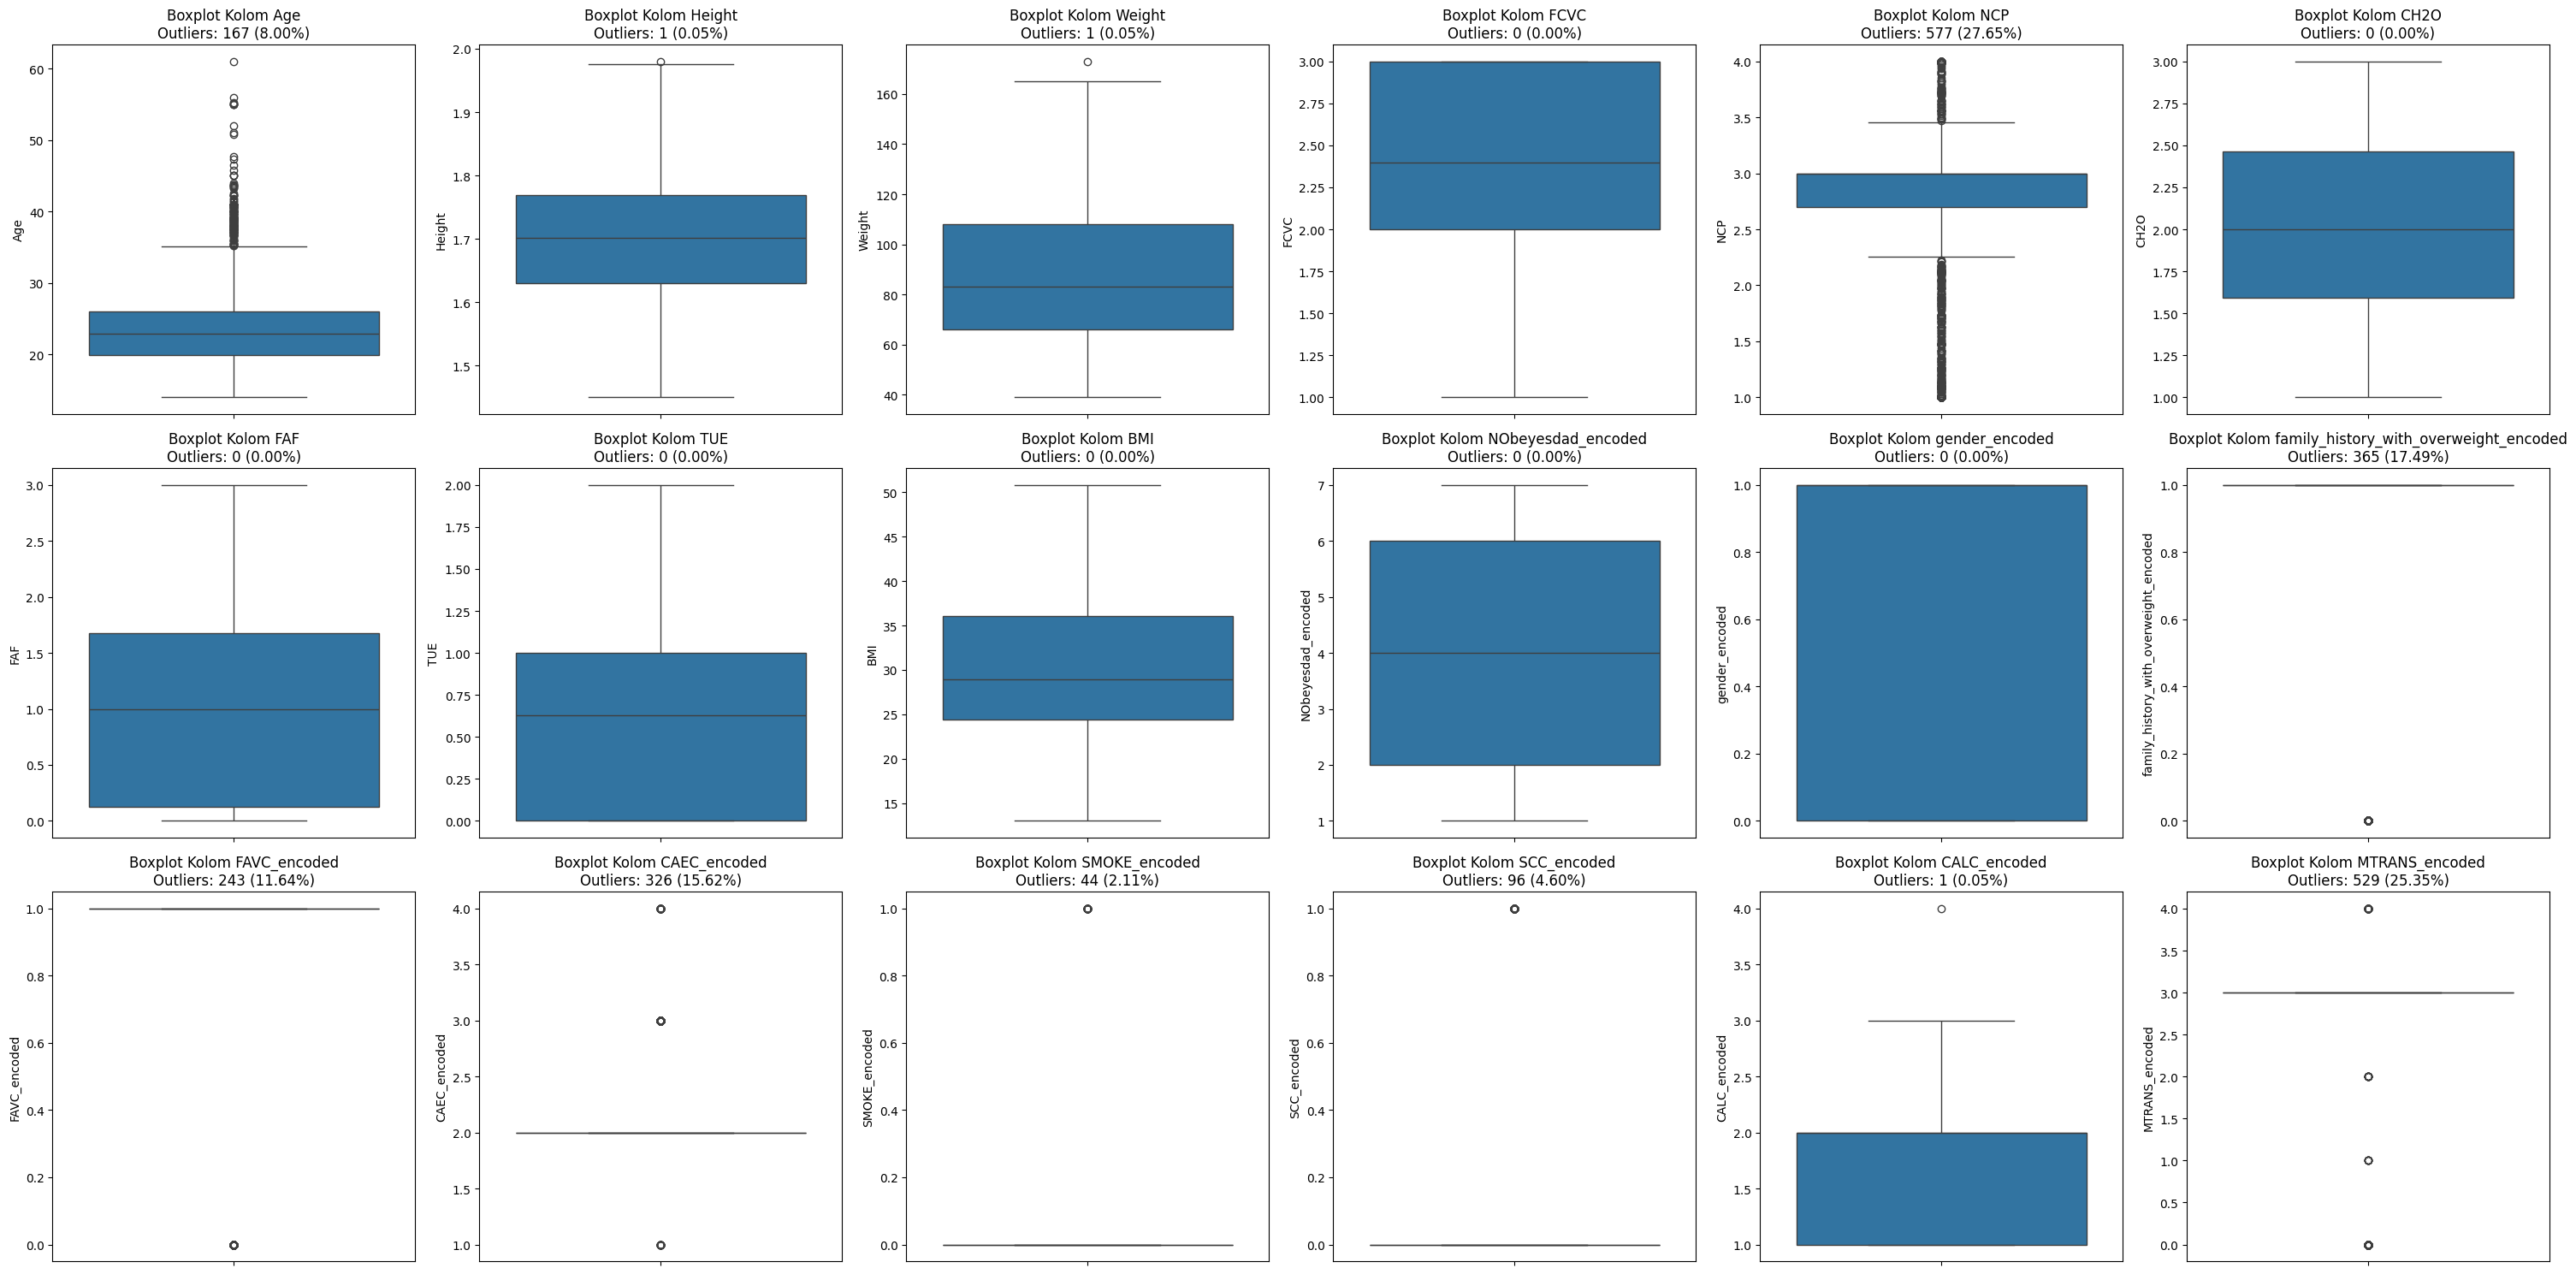

In [23]:
fig, axes = plt.subplots(3, 6, figsize=(30, 15))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot Kolom {col}\nOutliers: {outlier_count} ({outlier_percentage:.2f}%)')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### **Interpretasi Box Plot**
- Untuk Age, terlihat cukup banyak outlier (≈ 7,67%), terutama di usia yang lebih tua. Ini menunjukkan bahwa meskipun mayoritas data adalah usia muda, terdapat sebagian kecil individu dengan usia jauh di atas rata-rata yang bisa mempengaruhi analisis.<P>

- Pada Height, tidak ditemukan outlier sama sekali. Ini menandakan distribusi tinggi badan sangat stabil dan tidak memiliki nilai ekstrem.<P>

- Sementara itu, Weight hampir tidak memiliki outlier (hanya ≈ 0,05%), sehingga meskipun rentangnya besar, nilainya masih dianggap wajar dalam distribusi data.<P>

- Untuk FCVC, juga tidak terdapat outlier, yang menunjukkan pola konsumsi sayur cukup konsisten antar individu.<P>

- Berbeda dengan itu, NCP (jumlah makan utama) memiliki outlier yang sangat banyak (≈ 27,70%). Hal ini kemungkinan terjadi karena data bersifat diskrit (1–4 kali makan), sehingga secara statistik banyak nilai dianggap outlier meskipun sebenarnya masih masuk akal secara konteks.<P>

- Pada CH2O, tidak ditemukan outlier, menandakan konsumsi air relatif stabil.<P>

- Untuk FAF (aktivitas fisik) dan TUE (penggunaan teknologi), juga tidak terdapat outlier, sehingga variasinya masih dalam batas wajar.<P>

- Variabel BMI tidak menunjukkan outlier, meskipun rentangnya cukup lebar. Ini berarti nilai ekstrem BMI masih dianggap bagian dari distribusi utama data.<P>

- Pada NObeyesdad (kategori obesitas) dan Gender, tidak ada outlier karena memang berupa variabel kategorikal yang telah diencoding.<P>

- Untuk variabel biner seperti family_history_with_overweight (≈ 17,49% outlier) dan FAVC (≈ 11,64% outlier), banyaknya “outlier” sebenarnya disebabkan oleh ketidakseimbangan kelas (mayoritas bernilai 1), bukan karena nilai ekstrem secara nyata.<P>

- Pada variabel SMOKE, terdapat 44 outlier (2.11%) yang merupakan individu yang merokok dikarenakan mayoritas data tidak merokok

- Pada CAEC (≈ 15,62%), SCC (≈ 4,60%), dan MTRANS (≈ 25,35%), di mana outlier muncul akibat sifat kategorikal/discrete dari data, bukan karena anomali sebenarnya.<P>

- Untuk CALC (konsumsi alkohol), hampir tidak ada outlier (≈ 0,05%), menunjukkan distribusi yang cukup stabil.<P>

## Barchart Level Obesitas

/tmp/ipykernel_6910/297856251.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=counts.index, palette=colors)


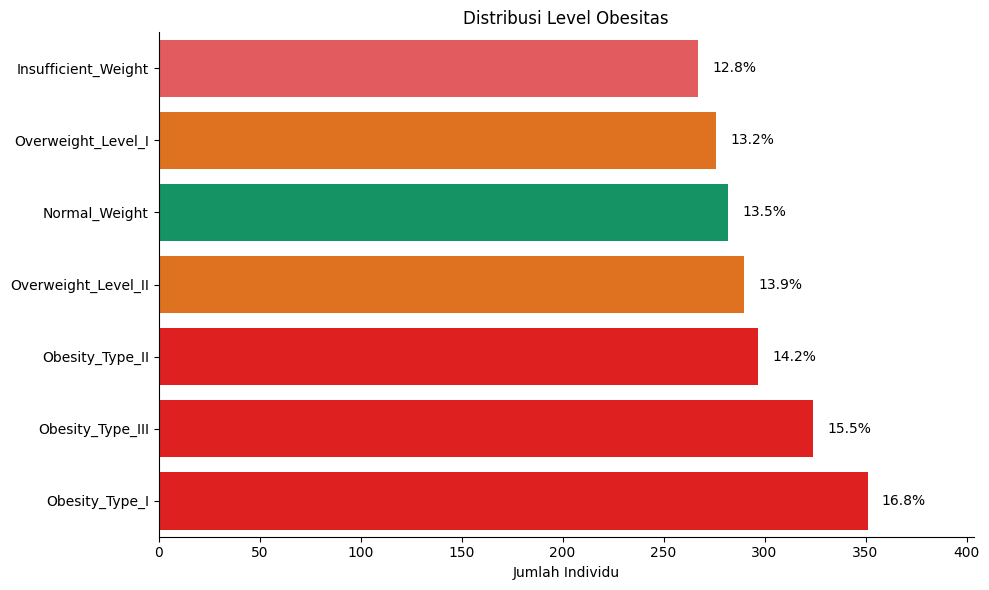

In [24]:
counts = df['NObeyesdad'].value_counts().sort_values(ascending=True)
total = counts.sum()

# warna sesuai aturan kamu (tanpa gradasi seaborn)
color_map = {
    'Insufficient_Weight': '#f94449',   # merah biasa
    'Normal_Weight': '#00a86b',         # hijau terang
    'Overweight_Level_I': '#ff6e00',    # merah sedang
    'Overweight_Level_II': '#ff6e00',
    'Obesity_Type_I': '#ff0000',        # merah pekat
    'Obesity_Type_II': '#ff0000',
    'Obesity_Type_III': '#ff0000'
}

colors = [color_map[i] for i in counts.index]

plt.figure(figsize=(10,6))
ax = sns.barplot(x=counts.values, y=counts.index, palette=colors)

# kasih ruang kanan biar label ga nabrak
plt.xlim(0, max(counts.values)*1.15)

# label persen
for i, v in enumerate(counts.values):
    ax.text(v + max(counts.values)*0.02, i, f"{100*v/total:.1f}%", va='center')

sns.despine()

plt.title('Distribusi Level Obesitas')
plt.xlabel('Jumlah Individu')
plt.ylabel('')
plt.tight_layout()
plt.show()

### **Interpretasi Horizontal Bar Chart :**
- Kategori dengan proporsi tertinggi adalah Obesity_Type_I (16,8%), diikuti oleh Obesity_Type_III (15,5%) dan Obesity_Type_II (14,2%). Ini menunjukkan bahwa cukup banyak individu dalam dataset sudah berada pada tingkat obesitas, bahkan hingga level yang lebih berat.<P>

- Sementara itu, kategori Normal_Weight (13,5%) dan Overweight_Level_I (13,2%) memiliki proporsi yang tidak jauh berbeda, yang berarti jumlah individu dengan kondisi normal relatif seimbang dengan yang mulai mengalami kelebihan berat badan.<P>

- Kategori dengan proporsi terendah adalah Insufficient_Weight (12,8%), namun selisihnya sangat kecil dibanding kategori lain. Hal ini menegaskan bahwa distribusi data cukup seimbang antar kelas.<P>

## Menampilkan Distribusi Kolom Kategorikal yang Dienkode

In [25]:
encoded_categorical_cols = [
    'NObeyesdad_encoded',
    'gender_encoded',
    'family_history_with_overweight_encoded',
    'FAVC_encoded',
    'CAEC_encoded',
    'SMOKE_encoded',
    'SCC_encoded',
    'CALC_encoded',
    'MTRANS_encoded'
]

reverse_mappings = {
    'NObeyesdad_encoded': {v: k for k, v in obesity_mapping.items()},
    'gender_encoded': {v: k for k, v in gender_mapping.items()},
    'family_history_with_overweight_encoded': {v: k for k, v in family_history_mapping.items()},
    'FAVC_encoded': {v: k for k, v in favc_mapping.items()},
    'CAEC_encoded': {v: k for k, v in caec_mapping.items()},
    'SMOKE_encoded': {v: k for k, v in smoke_mapping.items()},
    'SCC_encoded': {v: k for k, v in scc_mapping.items()},
    'CALC_encoded': {v: k for k, v in calc_mapping.items()},
    'MTRANS_encoded': {v: k for k, v in mtrans_mapping.items()}
}

for col_name in encoded_categorical_cols:
    print(f"\nDistribusi {col_name.replace('_encoded', '')}:")
    counts = df[col_name].value_counts().sort_index()
    total = counts.sum()

    # Gunakan reverse mapping untuk label yang lebih mudah dibaca
    reverse_map_dict = reverse_mappings.get(col_name)

    # Buat DataFrame untuk tampilan tabel
    table_data = []
    for label_val, count_val in counts.items():
        original_label = reverse_map_dict.get(label_val, label_val) if reverse_map_dict else label_val
        percentage = (count_val / total) * 100
        table_data.append({'Kategori': original_label, 'Jumlah': count_val, 'Persentase': f'{percentage:.1f}%'})

    display(pd.DataFrame(table_data))


Distribusi NObeyesdad:


,Kategori,Jumlah,Persentase
0,Insufficient_Weight,267,12.8%
1,Normal_Weight,282,13.5%
2,Overweight_Level_I,276,13.2%
3,Overweight_Level_II,290,13.9%
4,Obesity_Type_I,351,16.8%
5,Obesity_Type_II,297,14.2%
6,Obesity_Type_III,324,15.5%



Distribusi gender:


,Kategori,Jumlah,Persentase
0,Female,1035,49.6%
1,Male,1052,50.4%



Distribusi family_history_with_overweight:


...

,Kategori,Jumlah,Persentase
0,no,1991,95.4%
1,yes,96,4.6%



Distribusi CALC:


,Kategori,Jumlah,Persentase
0,no,636,30.5%
1,Sometimes,1380,66.1%
2,Frequently,70,3.4%
3,Always,1,0.0%



Distribusi MTRANS:


,Kategori,Jumlah,Persentase
0,Automobile,456,21.8%
1,Bike,7,0.3%
2,Motorbike,11,0.5%
3,Public_Transportation,1558,74.7%
4,Walking,55,2.6%


###**Interpretasi Distribusi Kolom Kategorikal :**

- Untuk NObeyesdad (level obesitas), distribusinya memang relatif merata di semua kategori (sekitar 12–17%) . Ini menunjukkan dataset tidak bias ke satu kelas tertentu, tetapi secara agregat tetap didominasi oleh kategori overweight hingga obesitas.<P>

- Untuk Gender, distribusi merata dengan female sebanyak 49.6% dan male sebanyak 50.4%

- Pada family_history_with_overweight, terlihat sangat tidak seimbang, di mana 82,5% individu memiliki riwayat keluarga overweight.<P>

- Hal yang sama juga terlihat pada FAVC (konsumsi makanan tinggi kalori), dengan 88,4% individu sering mengonsumsi makanan berkalori tinggi.<P>

- Untuk CAEC (kebiasaan ngemil), mayoritas besar berada di kategori “Sometimes” (84,4%), sedangkan yang benar-benar sering atau selalu ngemil jumlahnya jauh lebih kecil. <P>

- Pada SMOKE, mayoritas (97.9%) individu tidak merokok dan hanya(2.1%) individu yang merokok

- Pada SCC (monitoring kalori), distribusi sangat timpang, di mana 95,4% individu tidak memantau kalori . Ini menunjukkan rendahnya kesadaran atau kontrol terhadap pola makan dalam dataset.<P>

- Untuk CALC (konsumsi alkohol), mayoritas berada di kategori “Sometimes” (66,1%), diikuti oleh yang tidak konsumsi sama sekali (30,5%).<P>

- Terakhir, pada MTRANS (transportasi), mayoritas besar menggunakan Public Transportation (74,7%), diikuti oleh kendaraan bermotor (21,8%), sementara penggunaan transportasi aktif seperti jalan kaki (2,6%) dan sepeda (0,3%) sangat kecil . Ini menunjukkan gaya hidup yang cenderung kurang aktif secara fisik.<P>

## Explore Faktor Gaya Hidup per Kategori Obesitas (Pertanyaan 1)

In [26]:
lifestyle_vars = ['FAF', 'CH2O', 'TUE', 'FCVC', 'NCP']

# Define OBESITY_ORDER based on the logical progression of obesity levels
OBESITY_ORDER = [
    'Insufficient_Weight',
    'Normal_Weight',
    'Overweight_Level_I',
    'Overweight_Level_II',
    'Obesity_Type_I',
    'Obesity_Type_II',
    'Obesity_Type_III'
]

lifestyle_stats = df.groupby('NObeyesdad')[lifestyle_vars].mean().round(3)
lifestyle_stats = lifestyle_stats.reindex(OBESITY_ORDER)
print('Rata-rata variabel gaya hidup per kategori obesitas:')
print(lifestyle_stats)

# Highlight Normal vs Obesity_Type_III
print('''
--- Normal_Weight vs Obesity_Type_III ---''')
print(lifestyle_stats.loc[['Normal_Weight', 'Obesity_Type_III']])

Rata-rata variabel gaya hidup per kategori obesitas:
                       FAF   CH2O    TUE   FCVC    NCP
NObeyesdad                                            
Insufficient_Weight  1.274  1.884  0.848  2.475  2.943
Normal_Weight        1.252  1.858  0.677  2.337  2.748
Overweight_Level_I   1.060  2.011  0.644  2.278  2.581
Overweight_Level_II  0.958  2.025  0.697  2.261  2.496
Obesity_Type_I       0.987  2.112  0.677  2.186  2.432
Obesity_Type_II      0.972  1.878  0.515  2.391  2.745
Obesity_Type_III     0.665  2.208  0.605  3.000  3.000

--- Normal_Weight vs Obesity_Type_III ---
                    FAF   CH2O    TUE   FCVC    NCP
NObeyesdad                                         
Normal_Weight     1.252  1.858  0.677  2.337  2.748
Obesity_Type_III  0.665  2.208  0.605  3.000  3.000


###**Interpretasi Pertanyaan 1 :**
- Untuk FAF (aktivitas fisik) terlihat tren menurun secara konsisten. Dari sekitar 1.25 (Normal) turun sampai 0.66 (Obesity_Type_III). Ini menunjukkan bahwa semakin tinggi level obesitas, semakin rendah aktivitas fisiknya.<P>

- Untuk CH2O (konsumsi air), justru cenderung meningkat seiring naiknya level obesitas (dari 1.85 → 2.21). Artinya, konsumsi air tidak berkorelasi negatif dengan obesitas, bahkan cenderung lebih tinggi pada kelompok obesitas. <P>

- Pada TUE (penggunaan teknologi), nilainya relatif fluktuatif dan tidak ada tren jelas. Misalnya dari 0.67 (Normal) turun ke 0.60 (Obesity_Type_III), tapi tidak konsisten di semua level.<P>

- Untuk FCVC (konsumsi sayur), hasilnya cukup menarik karena justru meningkat hingga maksimum (3.00) pada Obesity_Type_III.<P>

- Pada NCP (jumlah makan utama), terlihat sedikit penurunan dari Normal (2.75) ke Obesity_Type_I (~2.43), tapi kemudian naik lagi di Obesity_Type_III (3.00). Artinya tidak ada pola linear yang jelas<P>

Normal vs Obesity_Type_III:

- FAF (aktivitas fisik) turun jauh (1.25 ke 0.66) yang menandakan ini perubahan paling signifikan
- CH2O (konsumsi air) naik (1.86 ke 2.21)
- TUE (penggunaan teknologi) sedikit turun (0.677 ke 0.605)
- FCVC (konsumsi sayur) naik ke maksimum (2.748 ke 3.000)
- NCP (jumlah makanan utama) naik sedikit (2.748 ke 3.000)
<P>

## Visualisasi Pertanyaan 1

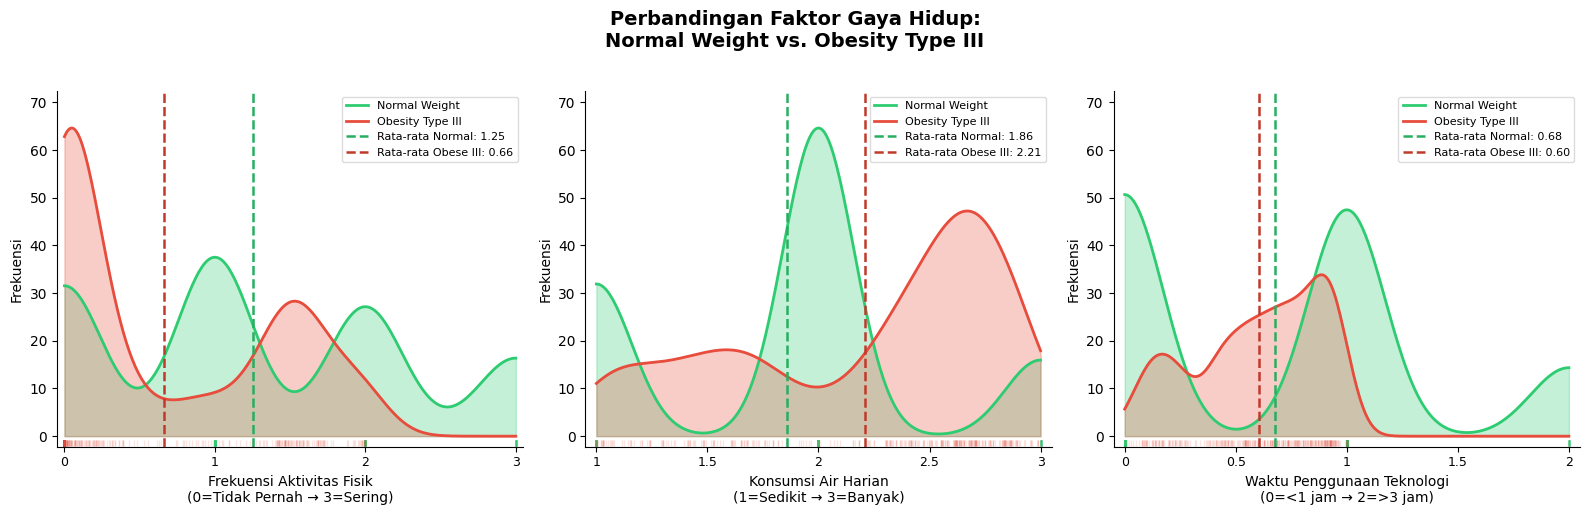

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
fig.suptitle(
    'Perbandingan Faktor Gaya Hidup:\nNormal Weight vs. Obesity Type III',
    fontsize=14, fontweight='bold', y=1.02
)

vars_info = [
    ('FAF', 'Frekuensi Aktivitas Fisik\n(0=Tidak Pernah → 3=Sering)', [0, 1, 2, 3]),
    ('CH2O', 'Konsumsi Air Harian\n(1=Sedikit → 3=Banyak)',           [1, 1.5, 2, 2.5, 3]),
    ('TUE', 'Waktu Penggunaan Teknologi\n(0=<1 jam → 2=>3 jam)',      [0, 0.5, 1, 1.5, 2]),
]

subset = df[df['NObeyesdad'].isin(['Normal_Weight', 'Obesity_Type_III'])].copy()

COLOR_N = '#2ecc71'
COLOR_O = '#e74c3c'

# Hitung y_max global dulu untuk sharey manual
global_ymax = 0
kde_cache = {}

for var, _, _ in vars_info:
    data_n = subset[subset['NObeyesdad'] == 'Normal_Weight'][var].dropna().values
    data_o = subset[subset['NObeyesdad'] == 'Obesity_Type_III'][var].dropna().values
    x_min  = min(data_n.min(), data_o.min())
    x_max  = max(data_n.max(), data_o.max())
    x_grid = np.linspace(x_min, x_max, 300)

    kde_n  = gaussian_kde(data_n, bw_method=0.25)
    kde_o  = gaussian_kde(data_o, bw_method=0.25)

    # Scale KDE ke frekuensi: density × n × (x_range / n_grid_points)
    bw_n   = kde_n.factor * data_n.std(ddof=1)
    bw_o   = kde_o.factor * data_o.std(ddof=1)
    y_n    = kde_n(x_grid) * len(data_n) * bw_n
    y_o    = kde_o(x_grid) * len(data_o) * bw_o

    kde_cache[var] = (x_grid, y_n, y_o, data_n, data_o, x_min, x_max)
    global_ymax = max(global_ymax, y_n.max(), y_o.max())

y_ceil = global_ymax * 1.12  # headroom 12%

for ax, (var, xlabel, xticks) in zip(axes, vars_info):
    x_grid, y_n, y_o, data_n, data_o, x_min, x_max = kde_cache[var]

    ax.fill_between(x_grid, y_n, alpha=0.28, color=COLOR_N)
    ax.fill_between(x_grid, y_o, alpha=0.28, color=COLOR_O)
    ax.plot(x_grid, y_n, color=COLOR_N, linewidth=2.0, label='Normal Weight')
    ax.plot(x_grid, y_o, color=COLOR_O, linewidth=2.0, label='Obesity Type III')

    # Rug
    rug_y = -y_ceil * 0.02
    ax.plot(data_n, np.full_like(data_n, rug_y), '|',
            color=COLOR_N, alpha=0.15, markersize=4)
    ax.plot(data_o, np.full_like(data_o, rug_y), '|',
            color=COLOR_O, alpha=0.15, markersize=4)

    # Mean lines
    mean_n = data_n.mean()
    mean_o = data_o.mean()
    ax.axvline(mean_n, color='#27ae60', linestyle='--', linewidth=1.8,
               label=f'Rata-rata Normal: {mean_n:.2f}')
    ax.axvline(mean_o, color='#c0392b', linestyle='--', linewidth=1.8,
               label=f'Rata-rata Obese III: {mean_o:.2f}')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Frekuensi', fontsize=10)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(v) for v in xticks], fontsize=9)
    ax.set_xlim(x_min - 0.05, x_max + 0.05)
    ax.set_ylim(rug_y - y_ceil * 0.01, y_ceil)
    ax.legend(fontsize=8, framealpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_pertanyaan1.png', bbox_inches='tight', dpi=150)
plt.show()

###**Interpretasi Visualisasi Pertanyaan 1 :**
- Pada FAF (aktivitas fisik), distribusi Obesity Type III memiliki frekuensi tinggi di anggka 0 hingga ~0.66 yang menginterpretasikan bahwa individu obesitas type III mayoritas jarang melakukan aktivitas fisik. Sedangkan, individu normal weight terlihat menyebar di beberapa puncak.<P>

- Untuk CH2O (konsumsi air), distribusi Obesity Type III cenderung minum lebih banyak air. Untuk individu normal weight terlihat cenderung minum air dengan konsumsi sedang<P>

- Pada TUE (penggunaan teknologi),distribusi Obesity Type III menunjukkan bahwa penggunakan teknologi berada di < 3 jam. Sedangkan, untuk normal weight cukup tersebar <P>

## Pertanyaan 2: Riwayat Keluarga vs Risiko Obesitas per Gender

In [28]:
cross_fam = pd.crosstab(
    [df['Gender'], df['family_history_with_overweight']],
    df['is_obese'],
    normalize='index'
).round(4) * 100
cross_fam.columns = ['Tidak Obesitas (%)', 'Obesitas (%)']
print('Persentase individu obesitas berdasarkan riwayat keluarga & gender:')
print(cross_fam)

Persentase individu obesitas berdasarkan riwayat keluarga & gender:
                                       Tidak Obesitas (%)  Obesitas (%)
Gender family_history_with_overweight                                  
Female no                                           99.12          0.88
       yes                                          40.79         59.21
Male   no                                           95.68          4.32
       yes                                          46.88         53.12


###**Interpretasi Pertanyaan 2**
- Pada individu yang tidak memiliki riwayat keluarga overweight, persentase yang tidak obesitas sangat tinggi, yaitu sebesar 99,12% pada perempuan dan 95,68% pada laki-laki, sehingga dapat dikatakan bahwa tanpa faktor riwayat keluarga, sebagian besar individu berada dalam kondisi tidak obesitas.<P>

- Sebaliknya, pada individu yang memiliki riwayat keluarga overweight, terjadi peningkatan yang sangat signifikan pada proporsi obesitas, yaitu sebesar 59,21% pada perempuan dan 53,12% pada laki-laki. Hal ini menunjukkan bahwa keberadaan riwayat keluarga berkaitan  dengan meningkatnya kemungkinan seseorang mengalami obesitas.<P>

- Jika dilihat dari perbandingan gender, perempuan dengan riwayat keluarga memiliki persentase obesitas yang sedikit lebih tinggi dibandingkan laki-laki, namun selisihnya tidak terlalu besar. Dengan demikian, perbedaan gender tidak memberikan pengaruh yang signifikan dibandingkan faktor riwayat keluarga.<P

## Visualisasi Pertanyaan 2

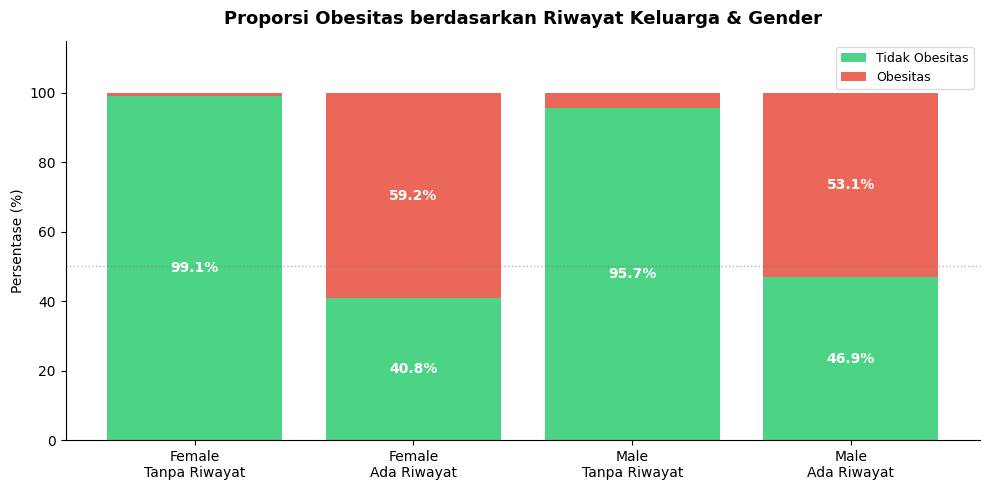

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

labels = [f"{g}\n{'Ada' if f == 'yes' else 'Tanpa'} Riwayat"
          for g, f in cross_fam.index]

not_obese = cross_fam['Tidak Obesitas (%)'].values
obese     = cross_fam['Obesitas (%)'].values
x         = np.arange(len(labels))

ax.bar(x, not_obese, color='#2ecc71', alpha=0.85, label='Tidak Obesitas')
ax.bar(x, obese, bottom=not_obese, color='#e74c3c', alpha=0.85, label='Obesitas')

for i, (n, o) in enumerate(zip(not_obese, obese)):
    if n > 8:
        ax.text(i, n / 2, f'{n:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')
    if o > 8:
        ax.text(i, n + o / 2, f'{o:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Persentase (%)', fontsize=10)
ax.set_ylim(0, 115)
ax.set_title(
    'Proporsi Obesitas berdasarkan Riwayat Keluarga & Gender',
    fontsize=13, fontweight='bold', pad=12
)
ax.axhline(50, color='gray', linestyle=':', linewidth=1, alpha=0.6)
ax.legend(fontsize=9, framealpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_pertanyaan2.png', bbox_inches='tight', dpi=150)
plt.show()

###**Interpretasi Visualisasi Pertanyaan 2 :**
- Pada visualisasi dapat dilihat bahwa riwayat overweight menunjukkan perubahan yang cukup signifikan kepada faktor obesitas. Dapat dilihat bahwa ~2.6 % obesitas tanpa riwayat melonjak ke angka ~56.15 %<P>

## Explore Transportasi vs. Kategori Obesitas (Pertanyaan 3)

In [30]:
trans_cross = pd.crosstab(
    df['NObeyesdad'],
    df['MTRANS'],
    normalize='index'
).round(4) * 100
trans_cross = trans_cross.reindex(OBESITY_ORDER)
print('Distribusi moda transportasi (%) per kategori obesitas:')
print(trans_cross[['Automobile', 'Public_Transportation', 'Walking', 'Bike']])

Distribusi moda transportasi (%) per kategori obesitas:
MTRANS               Automobile  Public_Transportation  Walking  Bike
NObeyesdad                                                           
Insufficient_Weight       17.23                  80.52     2.25  0.00
Normal_Weight             15.60                  69.86    10.99  1.42
Overweight_Level_I        23.91                  71.74     3.26  0.72
Overweight_Level_II       32.41                  65.17     2.07  0.00
Obesity_Type_I            31.34                  67.24     0.57  0.00
Obesity_Type_II           31.99                  67.34     0.34  0.34
Obesity_Type_III           0.31                  99.69     0.00  0.00


###**Interpretasi Pertanyaan 3 :**
- Pada kategori Insufficient_Weight hingga Normal_Weight, penggunaan Public Transportation memang dominan (sekitar 70–80%), namun masih terdapat proporsi Walking yang cukup terlihat, terutama pada Normal Weight (≈10,99%). Ini menunjukkan bahwa pada kelompok dengan berat badan lebih rendah, aktivitas fisik melalui transportasi masih relatif ada.<P>

- Seiring meningkatnya level obesitas, proporsi Walking menurun drastis, bahkan hampir tidak ada pada kategori Obesity_Type_I hingga Obesity_Type_III (mendekati 0%). Hal ini mengindikasikan bahwa individu dengan tingkat obesitas lebih tinggi cenderung tidak menggunakan transportasi aktif.<P>

- Sebaliknya, penggunaan Automobile cenderung meningkat dari sekitar 15–17% (Normal/Underweight) menjadi sekitar 31–32% pada kategori obesitas tipe I dan II. Ini menunjukkan adanya kecenderungan beralih ke transportasi yang lebih pasif.<P>

- Yang paling mencolok adalah pada Obesity_Type_III, di mana hampir seluruh individu (99,69%) menggunakan Public Transportation, dan hampir tidak ada yang berjalan kaki maupun menggunakan kendaraan aktif lainnya. Ini menunjukkan tingkat aktivitas fisik yang sangat rendah dalam mobilitas sehari-hari.<P>

## Visualisasi Pertanyaan 3

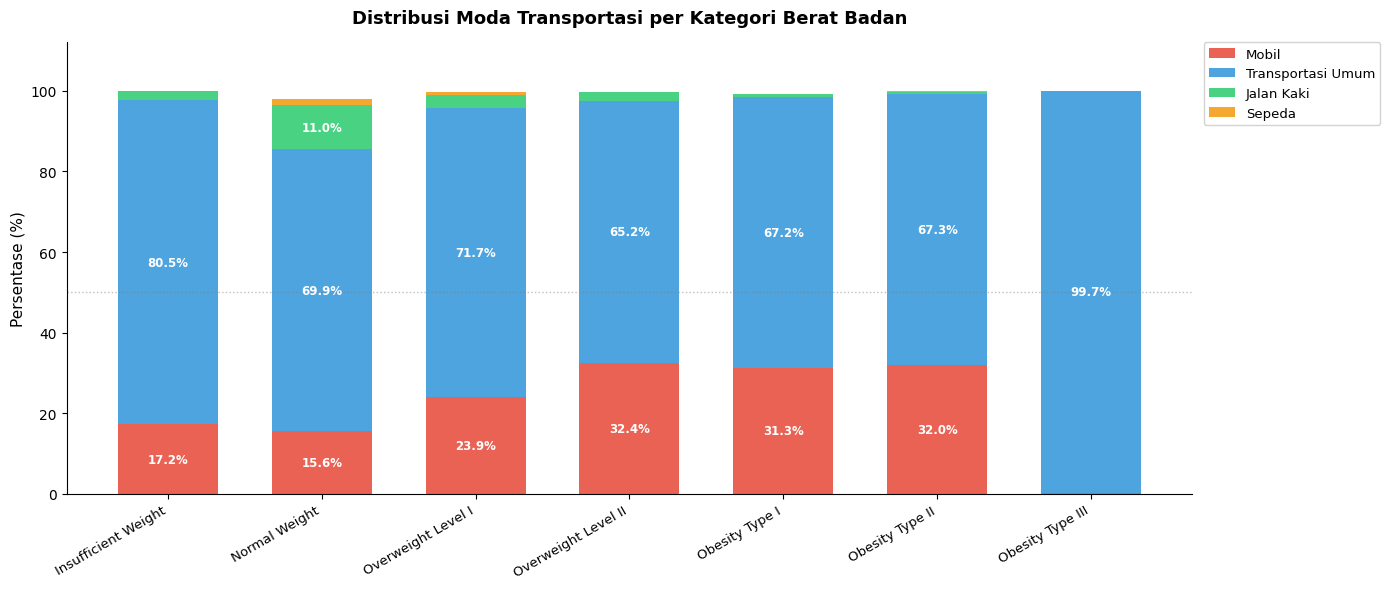

Visualisasi transportasi tersimpan.


In [31]:
cols   = ['Automobile', 'Public_Transportation', 'Walking', 'Bike']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
labels_transport = ['Mobil', 'Transportasi Umum', 'Jalan Kaki', 'Sepeda']

data   = trans_cross[cols].values
n_rows = len(data)
x      = np.arange(n_rows)

fig, ax = plt.subplots(figsize=(14, 6))

bottoms = np.zeros(n_rows)
for i, (col, color, lbl) in enumerate(zip(cols, colors, labels_transport)):
    vals = data[:, i]
    bars = ax.bar(x, vals, bottom=bottoms, color=color, alpha=0.88,
                  label=lbl, width=0.65)

    for j, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 5:
            ax.text(j, b + v / 2, f'{v:.1f}%',
                    ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color='white')
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(
    [lbl.replace('_', ' ') for lbl in trans_cross.index],
    fontsize=9.5, rotation=30, ha='right'
)

fig.subplots_adjust(bottom=0.18)

ax.set_ylabel('Persentase (%)', fontsize=11)
ax.set_ylim(0, 112)
ax.set_title(
    'Distribusi Moda Transportasi per Kategori Berat Badan',
    fontsize=13, fontweight='bold', pad=14
)
ax.axhline(50, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax.legend(
    fontsize=9.5,
    framealpha=0.85,
    loc='upper left',
    bbox_to_anchor=(1.01, 1),
    borderaxespad=0
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('viz_transportasi.png', bbox_inches='tight', dpi=150)
plt.show()
print('Visualisasi transportasi tersimpan.')

###**Interpretasi Visualisasi Pertanyaan 3 :**
- Pada kategori Insufficient_Weight hingga Normal_Weight, penggunaan transportasi umum mendominasi, yaitu sekitar 80,5% dan 69,9%, namun masih terdapat penggunaan jalan kaki yang cukup terlihat, khususnya pada Normal Weight sebesar 11,0%. Hal ini menunjukkan bahwa individu dengan berat badan lebih rendah masih memiliki aktivitas fisik dari mobilitas sehari-hari.<P>

- Seiring meningkatnya kategori menjadi Overweight hingga Obesity Type I dan II, penggunaan jalan kaki menurun drastis hingga hampir nol, sementara penggunaan mobil meningkat dari sekitar 15–17% menjadi lebih dari 30%. Hal ini mengindikasikan adanya pergeseran menuju transportasi yang lebih pasif.<P>

- Pada kategori Obesity_Type_III, hampir seluruh individu menggunakan transportasi umum (99,7%), tanpa adanya penggunaan jalan kaki maupun sepeda. Kondisi ini menunjukkan bahwa aktivitas fisik dari mobilitas sehari-hari практически tidak ada pada kelompok ini.<P>

- Secara keseluruhan, dapat disimpulkan bahwa semakin tinggi tingkat obesitas, semakin rendah penggunaan transportasi aktif seperti berjalan kaki, serta semakin tinggi ketergantungan pada transportasi pasif. Hal ini memperkuat bahwa rendahnya aktivitas fisik dalam kehidupan sehari-hari menjadi salah satu faktor yang berkaitan dengan meningkatnya tingkat obesitas.<P>